C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10960\4000523271.py:26: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, inertia_values, 'bo-', marker='o')


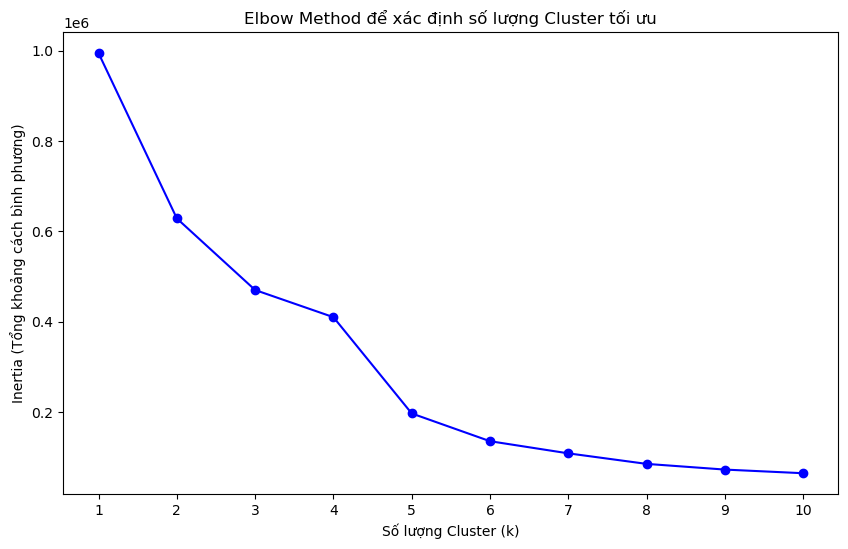

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10960\4000523271.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(range(2, 11), silhouette_scores_larger, 'bo-', marker='o')


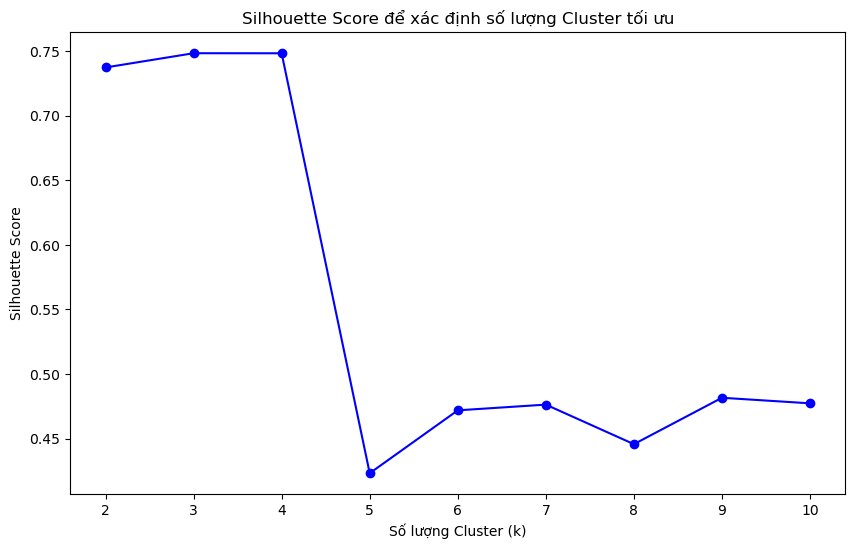

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Bước 1: Đọc dữ liệu
file_path = 'join (4).csv'
data = pd.read_csv(file_path)

# Bước 2: Chọn các cột quan trọng và chuẩn hóa dữ liệu
data_for_clustering = data[['LCY_CURR_BALANCE', 'Term', 'RATE']].dropna()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

# Bước 3: Elbow Method để xác định số lượng cluster tối ưu
inertia_values = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia_values, 'bo-', marker='o')
plt.xlabel('Số lượng Cluster (k)')
plt.ylabel('Inertia (Tổng khoảng cách bình phương)')
plt.title('Elbow Method để xác định số lượng Cluster tối ưu')
plt.xticks(K)
plt.show()

# Bước 4: Silhouette Score để xác định số lượng cluster tối ưu
sample_data_larger = data_scaled[:10000]  # Chọn 10000 mẫu ngẫu nhiên từ dữ liệu

silhouette_scores_larger = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(sample_data_larger)
    silhouette_avg = silhouette_score(sample_data_larger, labels)
    silhouette_scores_larger.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores_larger, 'bo-', marker='o')
plt.xlabel('Số lượng Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score để xác định số lượng Cluster tối ưu')
plt.xticks(range(2, 11))
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\2988648760.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['LCY_CURR_BALANCE'].fillna(data_cleaned['LCY_CURR_BALANCE'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\2988648760.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

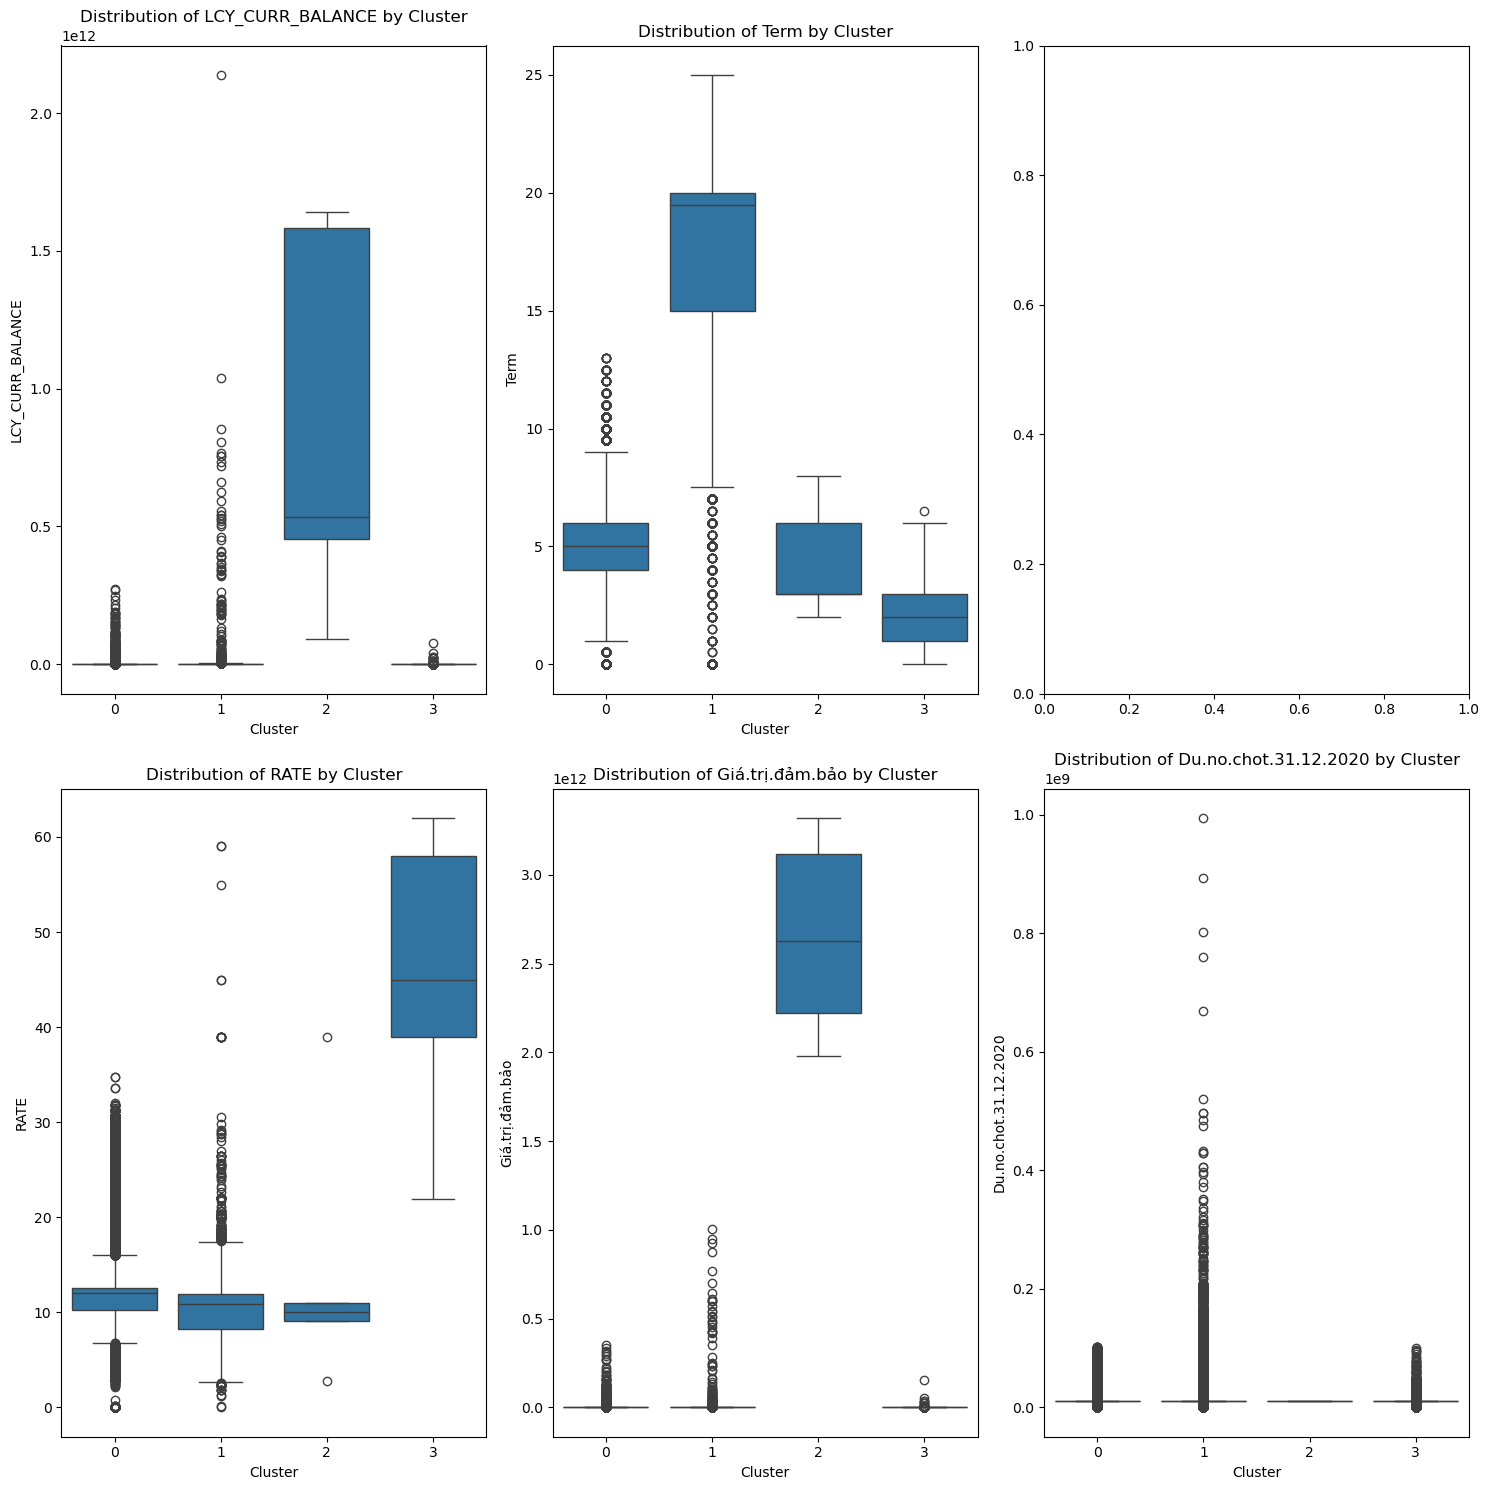

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Nạp dữ liệu
file_path = 'join (4).csv'
data = pd.read_csv(file_path)

# Chọn các cột liên quan đến phân cụm
selected_columns = [
    'LCY_CURR_BALANCE', 'Term', 'DESC', 'TERM',
    'CUSTOMER_TYPE', 'PRODUCT', 'NHOM_NO.1', 'INDUSTRY_CODE', 'VALUE_DATE',
    'RATE', 'LOANTYPE', 'CODE_DESC', 'OWNERSHIP', 'Nhóm.chốt.max',
    'Du.no.chot.31.12.2020', 'Lãi.quá.hạn.lũy.kế.hệ.thống',
    'Lãi.quá.hạn.lũy.kế.đã.thu', 'Lãi.quá.hạn.lũy.kế',
    'Dư.nợ.tính.dự.phòng', 'Tỷ.lệ.trích.lập',
    'Dự.phòng.cụ.thể..phải.trích.đến.31.12.2020', 'Giá.trị.đảm.bảo',
    'Số.tiền.QD.VND'
]
data_selected = data[selected_columns]

# Loại bỏ các hàng có nhiều giá trị thiếu
data_cleaned = data_selected.dropna(thresh=4)

# Điền các giá trị thiếu còn lại bằng phương pháp trung vị (median) cho các cột số, và mode cho cột phân loại
data_cleaned['LCY_CURR_BALANCE'].fillna(data_cleaned['LCY_CURR_BALANCE'].median(), inplace=True)
data_cleaned['Term'].fillna(data_cleaned['Term'].median(), inplace=True)
data_cleaned['RATE'].fillna(data_cleaned['RATE'].median(), inplace=True)
data_cleaned['Du.no.chot.31.12.2020'].fillna(data_cleaned['Du.no.chot.31.12.2020'].median(), inplace=True)
data_cleaned['Giá.trị.đảm.bảo'].fillna(data_cleaned['Giá.trị.đảm.bảo'].median(), inplace=True)
data_cleaned['Số.tiền.QD.VND'].fillna(data_cleaned['Số.tiền.QD.VND'].median(), inplace=True)

# Đối với các cột phân loại
data_cleaned['NHOM_NO.1'].fillna(data_cleaned['NHOM_NO.1'].mode()[0], inplace=True)
data_cleaned['LOANTYPE'].fillna(data_cleaned['LOANTYPE'].mode()[0], inplace=True)
data_cleaned['CUSTOMER_TYPE'].fillna(data_cleaned['CUSTOMER_TYPE'].mode()[0], inplace=True)
data_cleaned['CODE_DESC'].fillna(data_cleaned['CODE_DESC'].mode()[0], inplace=True)



# Chuẩn hóa dữ liệu (bao gồm cả các biến mới)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_cleaned[
    ['LCY_CURR_BALANCE', 'Term', 'RATE', 
     'Giá.trị.đảm.bảo','Du.no.chot.31.12.2020']
])

# Áp dụng K-means clustering với số cụm là 4
kmeans = KMeans(n_clusters=4, random_state=42)
data_cleaned['Cluster'] = kmeans.fit_predict(data_scaled)

# Phân tích phân phối các biến số trong từng cụm
fig, axes = plt.subplots(2, 3, figsize=(15, 15))

sns.boxplot(x='Cluster', y='LCY_CURR_BALANCE', data=data_cleaned, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of LCY_CURR_BALANCE by Cluster')

sns.boxplot(x='Cluster', y='Term', data=data_cleaned, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Term by Cluster')

sns.boxplot(x='Cluster', y='RATE', data=data_cleaned, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of RATE by Cluster')

sns.boxplot(x='Cluster', y='Giá.trị.đảm.bảo', data=data_cleaned, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Giá.trị.đảm.bảo by Cluster')

sns.boxplot(x='Cluster', y='Du.no.chot.31.12.2020', data=data_cleaned, ax=axes[1, 2])
axes[1, 2].set_title('Distribution of Du.no.chot.31.12.2020 by Cluster')

plt.tight_layout()
plt.show()


In [3]:
# In ra tên các cột trong DataFrame
print(data.columns)

Index(['Unnamed: 0', 'CIF', 'LCY_CURR_BALANCE', 'Term', 'DESC', 'TERM',
       'CUSTOMER_TYPE', 'PRODUCT', 'NHOM_NO.1', 'INDUSTRY_CODE', 'VALUE_DATE',
       'RATE', 'LOANTYPE', 'CODE_DESC', 'OWNERSHIP', 'Nhóm.chốt.max',
       'Du.no.chot.31.12.2020', 'Lãi.quá.hạn.lũy.kế.hệ.thống',
       'Lãi.quá.hạn.lũy.kế.đã.thu', 'Lãi.quá.hạn.lũy.kế',
       'Dư.nợ.tính.dự.phòng', 'Tỷ.lệ.trích.lập',
       'Dự.phòng.cụ.thể..phải.trích.đến.31.12.2020', 'Giá.trị.đảm.bảo',
       'Số.tiền.QD.VND'],
      dtype='object')


CODE_DESC  KHDN QUY MO KHA 1 (UPPER 1)  KHDN QUY MO KHA 2 (UPPER 2)  \
Cluster                                                               
0                             0.000574                     0.000219   
1                             0.000534                     0.000356   
2                                  NaN                          NaN   
3                             0.000005                     0.000005   

CODE_DESC  KHDN QUY MO LON 1 (BIGCORP 1)  KHDN QUY MO LON 2 (BIGCORP 2)  \
Cluster                                                                   
0                               0.000720                       0.000365   
1                               0.000890                       0.000831   
2                               0.400000                       0.400000   
3                               0.000018                            NaN   

CODE_DESC  KHDN QUY MO NHO (SMALL)  KHDN QUY MO VUA 1 (MEDIUM 1)  \
Cluster                                               

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\828175933.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\828175933.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\828175933.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17960\828175933.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

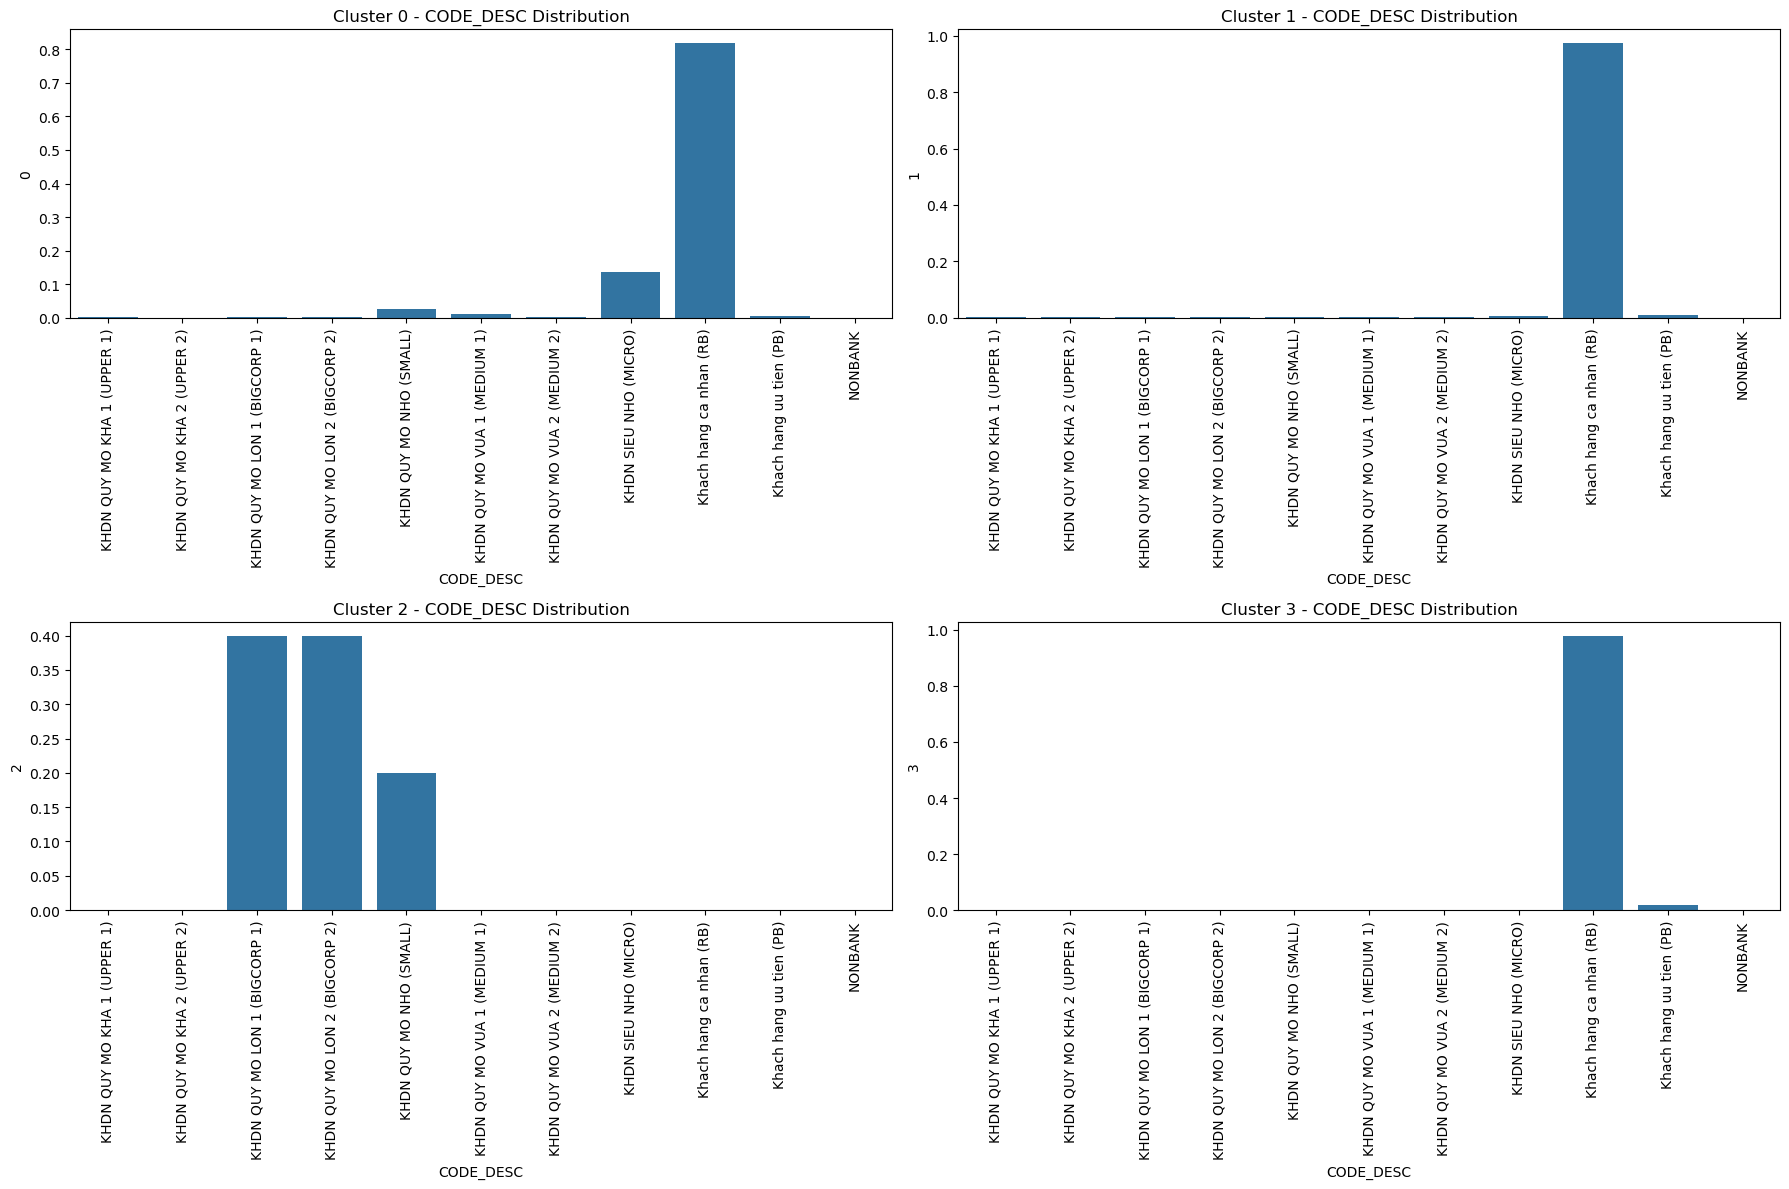

In [4]:
# Kiểm tra sự phân phối của 'CODE_DESC' trong từng cụm để miêu tả chân dung khách hàng
code_desc_distribution = data_cleaned.groupby('Cluster')['CODE_DESC'].value_counts(normalize=True).unstack()

# Hiển thị kết quả phân phối để phân tích
print(code_desc_distribution)

# Vẽ biểu đồ cột cho từng cụm
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
clusters = code_desc_distribution.index

for i, cluster in enumerate(clusters):
    ax = axes[i//2, i%2]
    sns.barplot(x=code_desc_distribution.columns, y=code_desc_distribution.loc[cluster], ax=ax)
    ax.set_title(f'Cluster {cluster} - CODE_DESC Distribution')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Nạp dữ liệu đã tải lên
file_path = 'join (4).csv'
data = pd.read_csv(file_path)

# Chọn các cột liên quan
selected_columns = [
    'LCY_CURR_BALANCE', 'Term',
    'RATE',
    'Du.no.chot.31.12.2020', 'Lãi.quá.hạn.lũy.kế.hệ.thống',
    'Lãi.quá.hạn.lũy.kế.đã.thu', 'Lãi.quá.hạn.lũy.kế',
    'Dư.nợ.tính.dự.phòng',
    'Dự.phòng.cụ.thể..phải.trích.đến.31.12.2020', 'Giá.trị.đảm.bảo',
]

# Lấy dữ liệu sạch và chuẩn hóa
data_selected = data[selected_columns].dropna()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Tạo nhãn cụm bằng K-means cho dữ liệu đã được làm sạch
kmeans = KMeans(n_clusters=4, random_state=42)
data_selected['Cluster'] = kmeans.fit_predict(data_scaled)

# Tách dữ liệu thành X và y
X = data_selected.drop('Cluster', axis=1)  # Sử dụng các thuộc tính làm đầu vào
y = data_selected['Cluster']  # Sử dụng nhãn cụm làm đầu ra

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = rf_model.predict(X_test)

# Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Xem tầm quan trọng của các thuộc tính
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

print("\nFeature Importances:\n", feature_importances)

Accuracy: 0.9894971355824316

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2235
           1       1.00      0.89      0.94        53
           3       0.99      0.98      0.98       854

    accuracy                           0.99      3142
   macro avg       0.99      0.95      0.97      3142
weighted avg       0.99      0.99      0.99      3142


Feature Importances:
                                             importance
Term                                          0.685019
Giá.trị.đảm.bảo                               0.086086
LCY_CURR_BALANCE                              0.082169
RATE                                          0.062755
Du.no.chot.31.12.2020                         0.044797
Dư.nợ.tính.dự.phòng                           0.034870
Lãi.quá.hạn.lũy.kế.hệ.thống                   0.001568
Lãi.quá.hạn.lũy.kế                            0.001025
Lãi.quá.hạn.lũy.kế.đã.thu                     0

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10960\182318415.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis')


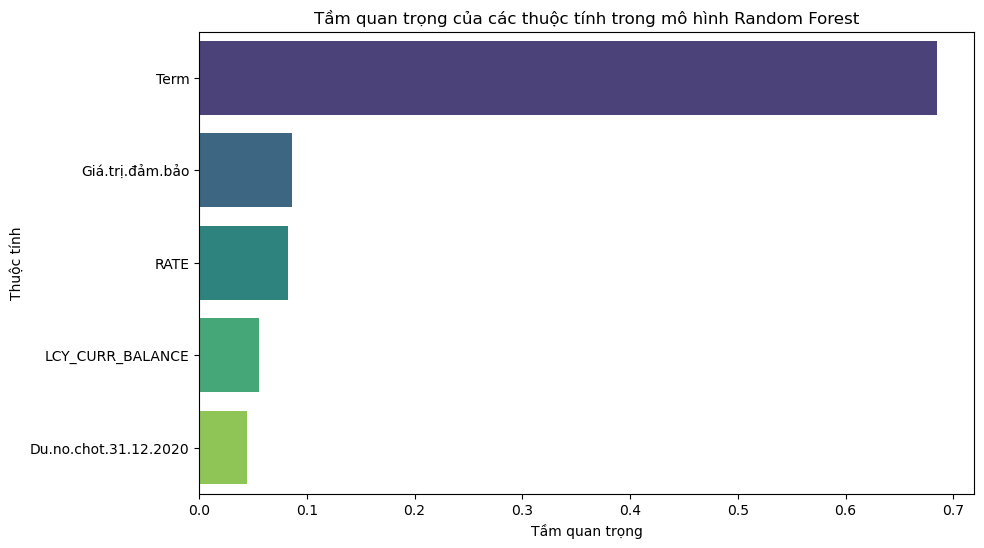

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = {
    'Term':  0.685019,
    'Du.no.chot.31.12.2020': 0.044797,
    'Giá.trị.đảm.bảo': 0.086086,
    'LCY_CURR_BALANCE': 0.056061,
    'RATE': 0.082169,
}

# Chuyển đổi sang DataFrame
feature_importances_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])

# Sắp xếp theo thứ tự quan trọng giảm dần
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ thanh (bar plot) để trực quan hóa tầm quan trọng của các thuộc tính
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis')
plt.title('Tầm quan trọng của các thuộc tính trong mô hình Random Forest')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Thuộc tính')
plt.show()

In [7]:
print("Training set distribution:")
print(y_train.value_counts())
print("\nTest set distribution:")
print(y_test.value_counts())

Training set distribution:
Cluster
0    5313
3    1882
1     133
2       1
Name: count, dtype: int64

Test set distribution:
Cluster
0    2235
3     854
1      53
Name: count, dtype: int64


In [8]:
# Lọc dữ liệu cho cụm 0
cluster_0 = data_selected[data_selected['Cluster'] == 0]

# Tính toán các thống kê mô tả cho cụm 0
statistics_cluster_0 = cluster_0.describe()

# Hiển thị các thống kê mô tả
print("Thống kê mô tả cho Cụm 0:")
print(statistics_cluster_0[['Term', 'Giá.trị.đảm.bảo', 'LCY_CURR_BALANCE']])

# So sánh các thống kê mô tả với các cụm khác
statistics_all_clusters = data_selected.groupby('Cluster')[['Term', 'Giá.trị.đảm.bảo', 'LCY_CURR_BALANCE']].describe()
print("\nSo sánh thống kê mô tả giữa các cụm:")
print(statistics_all_clusters)

Thống kê mô tả cho Cụm 0:
              Term  Giá.trị.đảm.bảo  LCY_CURR_BALANCE
count  7548.000000     7.548000e+03      7.548000e+03
mean      5.574126     7.310397e+08      5.321081e+08
std       2.222525     9.524797e+08      7.923462e+08
min       0.000000     0.000000e+00      1.440598e+05
25%       4.000000     3.269500e+08      2.034673e+08
50%       5.000000     4.875000e+08      3.273129e+08
75%       7.000000     7.607219e+08      5.448667e+08
max      14.500000     2.440392e+10      1.606675e+10

So sánh thống kê mô tả giữa các cụm:
           Term                                                      \
          count       mean       std  min   25%   50%     75%   max   
Cluster                                                               
0        7548.0   5.574126  2.222525  0.0   4.0   5.0   7.000  14.5   
1         186.0   8.443548  7.990926  0.0   0.0   7.0  14.875  25.0   
2           1.0   5.000000       NaN  5.0   5.0   5.0   5.000   5.0   
3        2736.0  18.1233

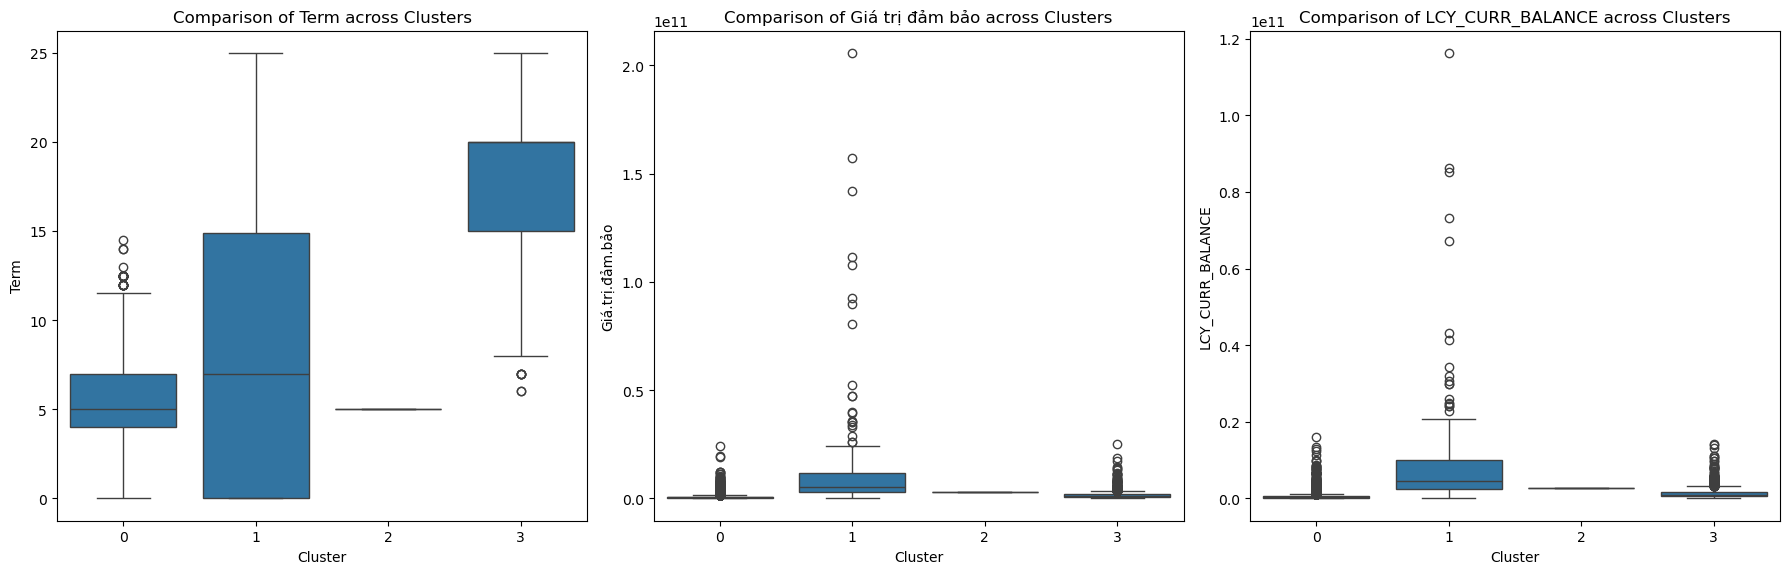

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc dữ liệu cho cụm 0
cluster_0 = data_selected[data_selected['Cluster'] == 0]

# Tính toán các thống kê mô tả cho cụm 0
statistics_cluster_0 = cluster_0.describe()

# So sánh các thống kê mô tả giữa các cụm
statistics_all_clusters = data_selected.groupby('Cluster')[['Term', 'Giá.trị.đảm.bảo', 'LCY_CURR_BALANCE']].describe()

# Trực quan hóa sự so sánh giữa cụm 0 và các cụm khác
plt.figure(figsize=(18, 6))

# Boxplot cho 'Term'
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Term', data=data_selected)
plt.title('Comparison of Term across Clusters')

# Boxplot cho 'Giá.trị.đảm.bảo'
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Giá.trị.đảm.bảo', data=data_selected)
plt.title('Comparison of Giá trị đảm bảo across Clusters')

# Boxplot cho 'LCY_CURR_BALANCE'
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='LCY_CURR_BALANCE', data=data_selected)
plt.title('Comparison of LCY_CURR_BALANCE across Clusters')

plt.tight_layout()
plt.show()

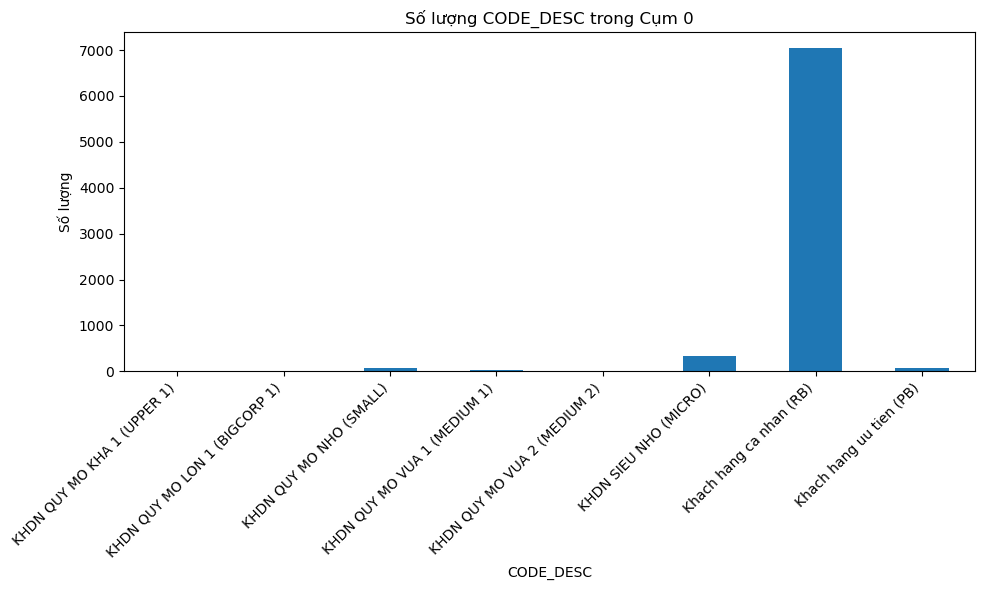

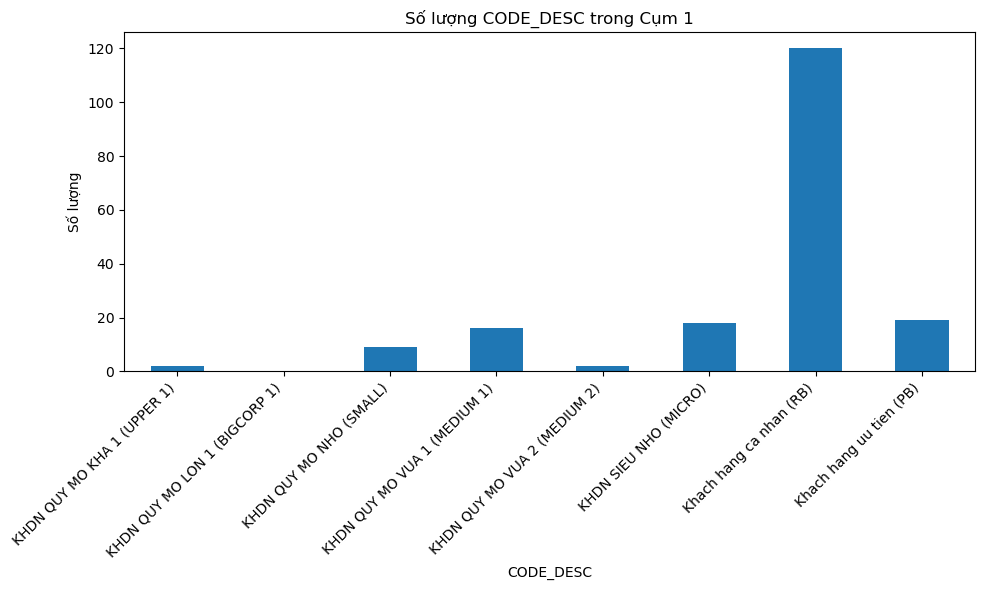

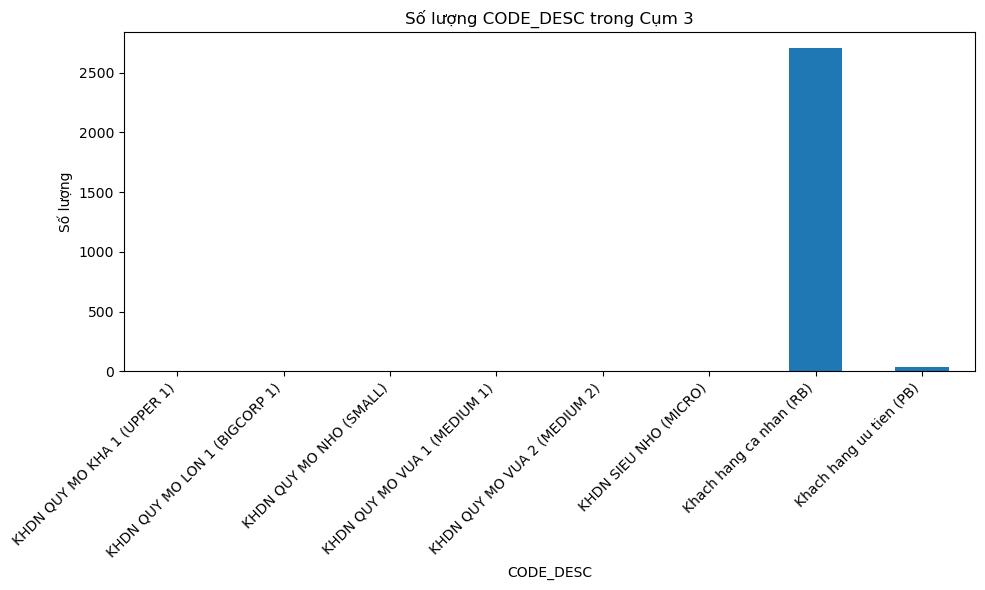

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Nạp dữ liệu
file_path = 'join (4).csv'
data = pd.read_csv(file_path)

# Chọn các cột liên quan
selected_columns = [
    'LCY_CURR_BALANCE', 'Term', 'RATE',
    'Du.no.chot.31.12.2020', 'Lãi.quá.hạn.lũy.kế.hệ.thống',
    'Lãi.quá.hạn.lũy.kế.đã.thu', 'Lãi.quá.hạn.lũy.kế',
    'Dư.nợ.tính.dự.phòng',
    'Dự.phòng.cụ.thể..phải.trích.đến.31.12.2020', 'Giá.trị.đảm.bảo',
    'CODE_DESC'
]

# Lấy dữ liệu sạch và chuẩn hóa
data_selected = data[selected_columns].dropna()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected.drop(columns=['CODE_DESC']))

# Tạo nhãn cụm bằng K-means cho dữ liệu đã được làm sạch
kmeans = KMeans(n_clusters=4, random_state=42)
data_selected['Cluster'] = kmeans.fit_predict(data_scaled)

# Đếm số lượng 'CODE_DESC' trong từng cụm
code_desc_count = data_selected.groupby(['Cluster', 'CODE_DESC']).size().unstack(fill_value=0)

# Tạo biểu đồ cột riêng lẻ cho từng cụm
clusters = [0, 1, 3]  # Chỉ vẽ các cụm có dữ liệu
for cluster in clusters:
    plt.figure(figsize=(10, 6))
    code_desc_count.loc[cluster].plot(kind='bar')
    plt.title(f'Số lượng CODE_DESC trong Cụm {cluster}')
    plt.xlabel('CODE_DESC')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()